<a href="https://colab.research.google.com/github/ferduart151/Hackademy/blob/main/notebooks/es/01_seurat_object.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Dentro de un objeto Seurat

**Taller de célula única CIAD**

Antes de empezar el análisis, vale la pena saber qué tienes en las manos.

Un objeto Seurat es un contenedor. Los counts (número de transcritos/moléculas por gen en cada célula) y cada resultado que calcules —
métricas de calidad, clusters, coordenadas UMAP, etiquetas de tipo celular — se guardan dentro
del mismo objeto. Eso es cómodo,
pero significa que el objeto se va llenando de cosas cuya ubicación no es obvia.

Este notebook lo abre. Los mismos datos que el resto del taller: 2,700 PBMCs
de 10x Genomics.

**Qué deberías poder hacer después**

- decir qué es un assay, un layer y una reduction
- sacar los counts, la metadata, los nombres de las células, los nombres de los genes
- agregar tu propia columna de metadata
- hacer un subset de un objeto sin romperlo
- encontrar dónde se guardó un resultado, sin adivinar

Unos 30 minutos. Ejecuta las celdas con *Shift + Enter*.

## Preparación

La primera celda instala los paquetes. Las líneas `library()` de la segunda celda
son la forma normal de cargar un paquete en R.

In [1]:
# This cell installs the packages we need. It is a shortcut for the workshop,
# so that nobody spends the class waiting for an install.
source("https://raw.githubusercontent.com/MartinLoza/CIAD_workshop_sc/main/setup/setup.R")

installing: Seurat, harmony, patchwork, hdf5r

also installing the dependencies ‘bitops’, ‘dotCall64’, ‘lazyeval’, ‘gtools’, ‘caTools’, ‘plyr’, ‘tensor’, ‘BH’, ‘sitmo’, ‘sp’, ‘spam’, ‘globals’, ‘listenv’, ‘parallelly’, ‘zoo’, ‘crosstalk’, ‘RcppTOML’, ‘here’, ‘gplots’, ‘reshape2’, ‘gridExtra’, ‘spatstat.data’, ‘spatstat.univar’, ‘spatstat.random’, ‘spatstat.utils’, ‘spatstat.sparse’, ‘goftest’, ‘abind’, ‘deldir’, ‘polyclip’, ‘FNN’, ‘dqrng’, ‘SeuratObject’, ‘cowplot’, ‘fastDummies’, ‘fitdistrplus’, ‘future’, ‘future.apply’, ‘ggrepel’, ‘ggridges’, ‘ica’, ‘igraph’, ‘irlba’, ‘lmtest’, ‘matrixStats’, ‘pbapply’, ‘plotly’, ‘png’, ‘progressr’, ‘RANN’, ‘RcppAnnoy’, ‘RcppHNSW’, ‘reticulate’, ‘ROCR’, ‘RSpectra’, ‘Rtsne’, ‘scattermore’, ‘sctransform’, ‘spatstat.explore’, ‘spatstat.geom’, ‘uwot’, ‘RcppEigen’, ‘RcppProgress’, ‘RhpcBLASctl’, ‘RcppArmadillo’


installing: presto (from GitHub, compiles)




  Seurat       5.5.1
  harmony      2.0.5
  patchwork    1.3.2
  dplyr        1.2.1
  ggplot2      4.0.3
  hdf5r        1.3.16
  presto       1.1.0

  ready in 114 seconds
  ✅ setup complete



In [2]:
# Change R language to English, in case your computer uses another language.
Sys.setenv(LANGUAGE = "en")

# This is the normal way to load a package in R. You will write lines like
# these at the top of every script you make.
library(Seurat)
library(ggplot2)
library(dplyr)
library(patchwork)

# Size of every figure in this notebook, in inches. Change these two numbers
# if a plot looks too small or too large.
options(repr.plot.width = 10, repr.plot.height = 7)

## 1. Antes del objeto: la matriz

Todo empieza como una matriz de counts. Genes en las filas, células en las columnas, y
cada entrada es el número de moléculas de ese gen detectadas en esa célula.

Descargamos esa matriz de 10x Genomics. Viene en tres archivos, que son la
salida estándar de 10x.

- `matrix.mtx` — los counts
- `barcodes.tsv` — una línea por célula
- `genes.tsv` — una línea por gen

In [3]:
url <- "https://cf.10xgenomics.com/samples/cell/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz"

download.file(url, "pbmc3k.tar.gz", quiet = TRUE)
untar("pbmc3k.tar.gz")

list.files("filtered_gene_bc_matrices/hg19")

[1] "barcodes.tsv" "genes.tsv"    "matrix.mtx"

### Qué hay dentro de esos archivos

Antes de cargar nada, mira los archivos mismos. Son texto plano.

In [4]:
dir <- "filtered_gene_bc_matrices/hg19"

# readLines(n = 3) stops after 3 lines; matrix.mtx has millions of them
cat("barcodes.tsv — one line per cell\n")
writeLines(readLines(file.path(dir, "barcodes.tsv"), n = 3))

cat("\ngenes.tsv — one line per gene\n")
writeLines(readLines(file.path(dir, "genes.tsv"), n = 3))

cat("\nmatrix.mtx — the counts\n")
writeLines(readLines(file.path(dir, "matrix.mtx"), n = 6))

barcodes.tsv — one line per cell
AAACATACAACCAC-1
AAACATTGAGCTAC-1
AAACATTGATCAGC-1

genes.tsv — one line per gene
ENSG00000243485	MIR1302-10
ENSG00000237613	FAM138A
ENSG00000186092	OR4F5

matrix.mtx — the counts
%%MatrixMarket matrix coordinate real general
%
32738 2700 2286884
32709 1 4
32707 1 1
32706 1 10


Tres cosas que notar.

- **`barcodes.tsv`** contiene los barcodes de las células, por ejemplo `AAACATACAACCAC-1`. Un barcode
  es una secuencia corta de DNA que se pegó a todo lo que salió de una
  gota (célula). Es simplemente el nombre de la célula.
- **`genes.tsv`** tiene dos columnas: el id de gen de Ensembl, y el símbolo del gen que
  leemos (`MS4A1`, `CD3E`). Seurat usa el símbolo.
- **`matrix.mtx`** empieza con dos líneas de encabezado. La siguiente línea da tres
  números: cuántos genes, cuántas células, y cuántos counts no son cero.
  Cada línea después de esa es un count, escrito como *número de gen, número de célula,
  count*.

Multiplica los primeros dos números y compara con el tercero. La tabla completa
tendría unos 88 millones de valores, y el archivo guarda solo unos pocos millones de ellos.
Los demás se toman como cero.

`Read10X()` lee esos tres archivos en una sola matriz: genes en las filas, células en
las columnas.

In [5]:
counts <- Read10X(data.dir = "filtered_gene_bc_matrices/hg19")

dim(counts)

[1] 32738  2700

32,738 genes y 2,700 células. Veamos una esquina — cinco genes,
cinco células.

In [6]:
counts[1:5, 1:5]

5 x 5 sparse Matrix of class "dgCMatrix"
             AAACATACAACCAC-1 AAACATTGAGCTAC-1 AAACATTGATCAGC-1
MIR1302-10                  .                .                .
FAM138A                     .                .                .
OR4F5                       .                .                .
RP11-34P13.7                .                .                .
RP11-34P13.8                .                .                .
             AAACCGTGCTTCCG-1 AAACCGTGTATGCG-1
MIR1302-10                  .                .
FAM138A                     .                .
OR4F5                       .                .
RP11-34P13.7                .                .
RP11-34P13.8                .                .

Todos son ceros (.), lo cual no es un error. Escoge genes que sí estén expresados
y el panorama cambia.

In [7]:
counts[c("CD3D", "CD3E", "MS4A1", "CD14", "LYZ"), 1:5]

5 x 5 sparse Matrix of class "dgCMatrix"
      AAACATACAACCAC-1 AAACATTGAGCTAC-1 AAACATTGATCAGC-1 AAACCGTGCTTCCG-1
CD3D                 4                .               10                .
CD3E                 2                .                2                .
MS4A1                .                6                .                .
CD14                 .                .                .                .
LYZ                  1                3                2               24
      AAACCGTGTATGCG-1
CD3D                 .
CD3E                 .
MS4A1                .
CD14                 .
LYZ                  .

### Por qué los puntos

Nota el `.` en lugar del `0`.

Esta no es una matriz ordinaria. Es una matriz **dispersa** — clase `dgCMatrix` —
que guarda solo las entradas distintas de cero. Un punto significa "aquí no hay nada guardado",
es decir, cero.

Eso importa más de lo que parece. La mayoría de las entradas en datos de célula única son cero,
y guardarlas todas sería un desperdicio, al punto de ser imposible.

In [8]:
cat("class:", class(counts), "\n\n")

zeros <- 1 - length(counts@x) / (nrow(counts) * ncol(counts))
cat(sprintf("entries that are zero: %.1f%%\n\n", 100 * zeros))

cat("sparse :", format(object.size(counts), units = "MB"), "\n")
cat("dense  :", format(object.size(as.matrix(counts[1:2000, ])) * (nrow(counts) / 2000),
                      units = "MB"), "(estimated)\n")

class: dgCMatrix 

entries that are zero: 97.4%

sparse : 28.5 Mb 
dense  : 680.2 Mb (estimated)


## 2. Crear el objeto

`CreateSeuratObject()` envuelve esa matriz en algo que puede cargar resultados.

In [9]:
pbmc <- CreateSeuratObject(
  counts       = counts,
  project      = "pbmc3k",
  min.cells    = 3,
  min.features = 200
)

pbmc

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”


An object of class Seurat 
13714 features across 2700 samples within 1 assay 
Active assay: RNA (13714 features, 0 variable features)
 1 layer present: counts

Lee ese resumen línea por línea. Dice:

- 13,714 features (genes); 2,700 samples (células)
- un **assay**, `RNA`, que es el **activo**
    - tenemos 0 variable features, esto es esperado porque no los hemos calculado (lo haremos en los siguientes pasos)
- un **layer**, llamado `counts`; aquí están los datos crudos.

Menos genes de los que empezamos — `min.cells = 3` descartó genes vistos en casi
ninguna célula.

### El vocabulario

| término | qué significa |
|---|---|
| **assay** | un tipo de medición sobre las mismas células — aquí `RNA`. Otro tipo de datos, como un experimento CITE-seq, también tendría `ADT` para proteínas de superficie. La integración agrega un assay corregido junto al original. |
| **layer** | una versión de la matriz dentro de un assay: `counts` es cruda, `data` normalizada, `scale.data` centrada y escalada. Mismas células, mismos genes, números distintos. (Seurat v4 los llamaba *slots*.) |
| **metadata** | una fila por célula, una columna por información extra: métricas de calidad, muestra de origen, cluster, tipo celular. |
| **reduction** | una representación en pocas dimensiones — PCA, UMAP. Una fila por célula y varias columnas. |
| **identity** | la etiqueta actual de la célula. Lo que devuelve `Idents()`. Es lo que las gráficas usan para colorear y lo que compara la expresión diferencial. |

El resto de este notebook es dónde vive cada una de esas cosas y cómo llegar a ellas.

## 3. Assays y layers

Un assay es una caja con nombre. Enlístalos, y mira cuál está activo.

In [10]:
cat("assays        :", Assays(pbmc), "\n")
cat("active assay  :", DefaultAssay(pbmc), "\n")
cat("layers in RNA :", Layers(pbmc[["RNA"]]), "\n")

assays        : RNA 
active assay  : RNA 
layers in RNA : counts 


Un solo layer por ahora, porque no hemos normalizado. Hazlo y aparece un segundo
— los counts crudos no se reemplazan.

In [11]:
pbmc <- NormalizeData(pbmc, verbose = FALSE)

Layers(pbmc[["RNA"]])

[1] "counts" "data"

### Sacar la matriz

`LayerData()` es el accesor. Nombra el assay y el layer que quieres.

**NOTA**:
También puedes acceder a los datos internos con `@` y `$`, pero el
acomodo interno puede cambiar entre versiones de Seurat — los accesores no. Usa el
accesor.

In [12]:
raw  <- LayerData(pbmc, assay = "RNA", layer = "counts")
norm <- LayerData(pbmc, assay = "RNA", layer = "data")

genes <- c("CD3D", "MS4A1", "CD14", "LYZ", "PPBP")
cells <- colnames(pbmc)[1:5]

cat("--- counts (raw molecules) ---\n")
print(raw[genes, cells])

cat("\n--- data (log-normalised) ---\n")
print(round(norm[genes, cells], 2))

--- counts (raw molecules) ---
5 x 5 sparse Matrix of class "dgCMatrix"
      AAACATACAACCAC-1 AAACATTGAGCTAC-1 AAACATTGATCAGC-1 AAACCGTGCTTCCG-1
CD3D                 4                .               10                .
MS4A1                .                6                .                .
CD14                 .                .                .                .
LYZ                  1                3                2               24
PPBP                 .                .                .                1
      AAACCGTGTATGCG-1
CD3D                 .
MS4A1                .
CD14                 .
LYZ                  .
PPBP                 .

--- data (log-normalised) ---
5 x 5 sparse Matrix of class "dgCMatrix"
      AAACATACAACCAC-1 AAACATTGAGCTAC-1 AAACATTGATCAGC-1 AAACCGTGCTTCCG-1
CD3D              2.86             .                3.49             .   
MS4A1             .                2.58             .                .   
CD14              .                .                

Mismos genes, mismas células, dos layers. El layer crudo tiene números enteros —
moléculas contadas. El layer normalizado tiene decimales, corregidos por cuánto
RNA dio cada célula y luego transformados con logaritmo.

Los ceros siguen siendo cero en todo momento. La normalización no crea expresión nueva.

## 4. Metadata

Una fila por célula. Aquí vive todo lo que sabes (anotas) *acerca de* las células; esto es distinto de su expresión génica.

In [13]:
dim(pbmc@meta.data)
# alternatively
# dim(pbmc[[]])

head(pbmc@meta.data, 5)
# head(pbmc[[]], 5)

[1] 2700    3

,orig.ident,nCount_RNA,nFeature_RNA
,<fct>,<dbl>,<int>
AAACATACAACCAC-1,pbmc3k,2419,779
AAACATTGAGCTAC-1,pbmc3k,4903,1352
AAACATTGATCAGC-1,pbmc3k,3147,1129
AAACCGTGCTTCCG-1,pbmc3k,2639,960
AAACCGTGTATGCG-1,pbmc3k,980,521


Tres columnas ya, y no agregamos ninguna:

- `orig.ident` — el nombre de `project` que pasamos
- `nCount_RNA` — total de moléculas (transcritos) en la célula
- `nFeature_RNA` — número de genes detectados en la célula

Las últimas dos las calculó `CreateSeuratObject()` porque se necesitan seguido.

### Dos formas de leer una columna

`pbmc$nombre` es la forma corta. `pbmc[["nombre"]]` devuelve un data frame en lugar de un
vector.

In [14]:
summary(pbmc$nFeature_RNA)

cat("\nvector      :", class(pbmc$nCount_RNA), "\n")
cat("data frame  :", class(pbmc[["nCount_RNA"]]), "\n")

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  212.0   690.0   816.0   845.5   952.0  3400.0 


vector      : numeric 
data frame  : data.frame 


### Agregar una columna

Asigna con `$` un valor por célula, en el orden en que están las células.

In [15]:
pbmc$percent.mt <- PercentageFeatureSet(pbmc, pattern = "^MT-")

# anything you can to add to the meta data could work — here, a simple size label for example
pbmc$size <- ifelse(pbmc$nCount_RNA > median(pbmc$nCount_RNA), "large", "small")

head(pbmc@meta.data, 3)

table(pbmc$size)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,size
,<fct>,<dbl>,<int>,<dbl>,<chr>
AAACATACAACCAC-1,pbmc3k,2419,779,3.0177759,large
AAACATTGAGCTAC-1,pbmc3k,4903,1352,3.7935958,large
AAACATTGATCAGC-1,pbmc3k,3147,1129,0.8897363,large



large small 
 1349  1351 

### ✏️ Ejercicio 1

Agrega una columna llamada `high.mito` que sea `TRUE` cuando el porcentaje
mitocondrial de una célula sea mayor a 5, y `FALSE` en los demás casos. Después cuenta cuántas células son.

Llena el espacio en blanco:

In [16]:
# pbmc$high.mito <- ______
# table(pbmc$high.mito)

## 5. Células y genes

In [17]:
cat("cells:", ncol(pbmc), " genes:", nrow(pbmc), "\n\n")

cat("first 3 cell names:\n"); print(head(Cells(pbmc), 3))
cat("\nfirst 3 gene names:\n"); print(head(Features(pbmc), 3))

cells: 2700  genes: 13714 

first 3 cell names:
[1] "AAACATACAACCAC-1" "AAACATTGAGCTAC-1" "AAACATTGATCAGC-1"

first 3 gene names:
[1] "AL627309.1"    "AP006222.2"    "RP11-206L10.2"


Los nombres de las células son los barcodes de 10x — la etiqueta de DNA que identificó la gota.
Son los nombres de fila del objeto en la metadata y sus nombres de columna en la
matriz, y Seurat los mantiene alineados por ti.

`colnames()` y `rownames()` también funcionan y significan lo mismo.

In [18]:
identical(Cells(pbmc), colnames(pbmc))
identical(Features(pbmc), rownames(pbmc))

[1] TRUE

[1] TRUE

## 6. Identities

La identity es la etiqueta actual de la célula — con la que las gráficas colorean, y la que
la expresión diferencial usa para agrupar.

Ahora mismo todas las células tienen la misma, porque no hemos hecho clustering. Está usando el nombre del proyecto que pusimos al crear el objeto Seurat.

In [19]:
head(Idents(pbmc), 3)
table(Idents(pbmc))

AAACATACAACCAC-1 AAACATTGAGCTAC-1 AAACATTGATCAGC-1 
          pbmc3k           pbmc3k           pbmc3k 
Levels: pbmc3k


pbmc3k 
  2700 

Puedes poner identities desde cualquier columna de metadata, y regresarlas. Vale
la pena practicar esto, porque es una de las formas más comunes de confundirse.

In [20]:
Idents(pbmc) <- "size"          # use the column we invented
table(Idents(pbmc))

Idents(pbmc) <- "orig.ident"    # and back
table(Idents(pbmc))


large small 
 1349  1351 


pbmc3k 
  2700 

## 7. Dónde van los resultados

Para mostrar reductions y grafos necesitamos haber calculado algunos. Esta celda corre el
pipeline estándar, rápido y en silencio — el notebook 02 es donde explicamos qué
hace cada paso y por qué. Por ahora, observa qué le agrega al objeto.

In [21]:
pbmc <- FindVariableFeatures(pbmc, verbose = FALSE)
pbmc <- ScaleData(pbmc, verbose = FALSE)
pbmc <- RunPCA(pbmc, verbose = FALSE)
pbmc <- FindNeighbors(pbmc, dims = 1:10, verbose = FALSE)
pbmc <- FindClusters(pbmc, resolution = 0.5, verbose = FALSE)
pbmc <- RunUMAP(pbmc, dims = 1:10, verbose = FALSE)

pbmc

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


An object of class Seurat 
13714 features across 2700 samples within 1 assay 
Active assay: RNA (13714 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

Compara ese resumen con el de la sección 2. El objeto ahora reporta tres
layers, y dos reductions.

Todo se guarda dentro del mismo objeto. Nada se pierde.

In [22]:
cat("layers     :", Layers(pbmc[["RNA"]]), "\n")
cat("reductions :", Reductions(pbmc), "\n")
cat("graphs     :", Graphs(pbmc), "\n")
cat("metadata   :", paste(colnames(pbmc@meta.data), collapse = ", "), "\n")

layers     : counts data scale.data 
reductions : pca umap 
graphs     : RNA_nn RNA_snn 
metadata   : orig.ident, nCount_RNA, nFeature_RNA, percent.mt, size, RNA_snn_res.0.5, seurat_clusters 


Nota que `seurat_clusters` apareció solo en la metadata — `FindClusters()`
lo escribe ahí, y también lo pone como la identity.

### Reductions

Una reduction (resultado de una reducción de dimensiones) es una matriz: una fila por célula, una columna por dimensión.
`Embeddings()` obtiene las coordenadas de las células.

In [23]:
pca  <- Embeddings(pbmc, reduction = "pca")
umap <- Embeddings(pbmc, reduction = "umap")

cat("pca  :", nrow(pca),  "cells x", ncol(pca),  "components\n")
cat("umap :", nrow(umap), "cells x", ncol(umap), "dimensions\n\n")

round(umap[1:5, ], 3)

pca  : 2700 cells x 50 components
umap : 2700 cells x 2 dimensions



,umap_1,umap_2
AAACATACAACCAC-1,-3.504,-3.966
AAACATTGAGCTAC-1,-4.562,11.919
AAACATTGATCAGC-1,-1.242,-0.797
AAACCGTGCTTCCG-1,10.189,1.189
AAACCGTGTATGCG-1,-9.719,-3.100


Esos dos números por célula son toda la gráfica UMAP. `DimPlot()` los dibuja,
pero aquí no hay magia — podrías graficarlos tú mismo.

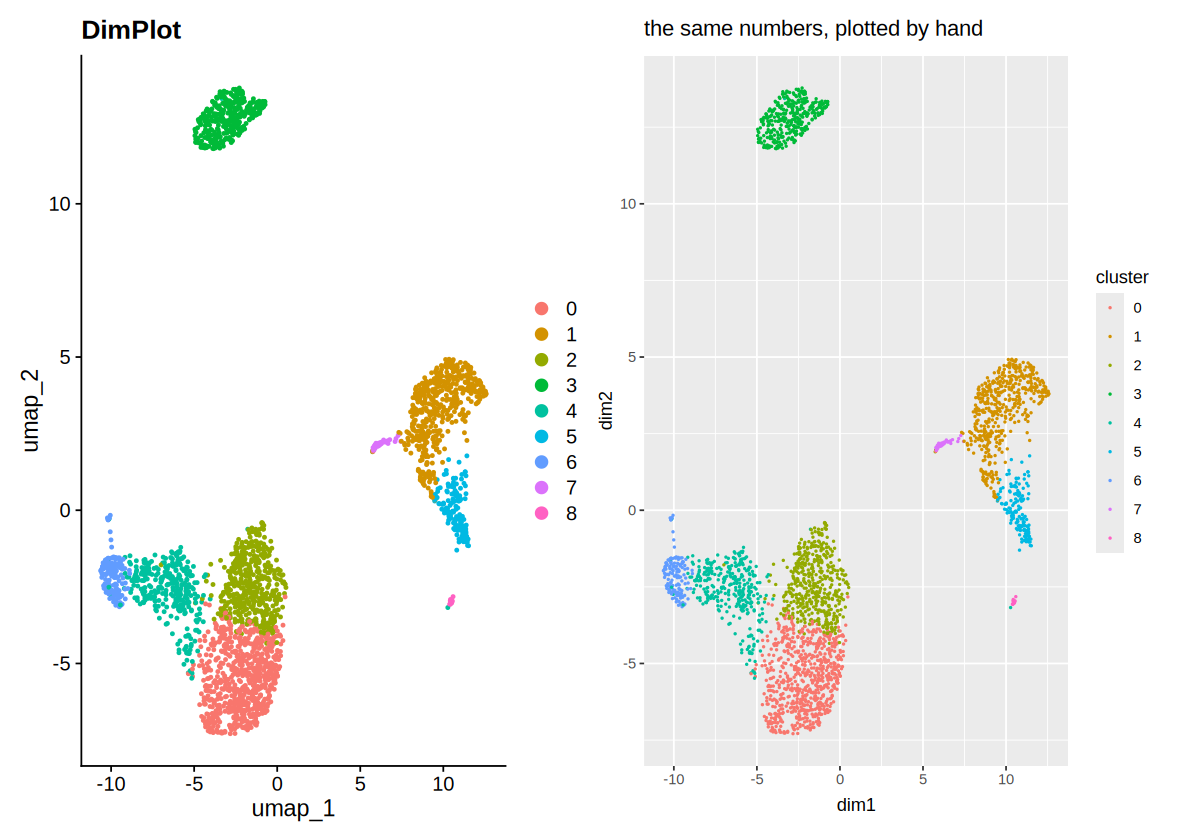

In [24]:
p1 <- DimPlot(pbmc, reduction = "umap") + ggtitle("DimPlot")

df <- as.data.frame(umap)
colnames(df) <- c("dim1", "dim2")   # whatever Seurat named them
df$cluster <- pbmc$seurat_clusters

p2 <- ggplot(df, aes(dim1, dim2, colour = cluster)) +
  geom_point(size = 0.3) +
  ggtitle("the same numbers, plotted by hand")

p1 + p2

`Loadings()` obtiene la otra parte de una transformación PCA: cuánto aporta cada **gen**
a cada componente.

In [25]:
loadings <- Loadings(pbmc, reduction = "pca")

cat(nrow(loadings), "genes x", ncol(loadings), "components\n\n")
round(loadings[1:5, 1:3], 3)

2000 genes x 50 components



,PC_1,PC_2,PC_3
PPBP,-0.012,0.015,-0.148
S100A9,-0.119,0.021,-0.027
IGLL5,0.009,0.055,0.055
LYZ,-0.120,0.016,-0.015
GNLY,0.015,-0.130,0.033


### ✏️ Ejercicio 2

¿Cuáles cinco genes jalan más fuerte sobre el PC 1, en cualquier dirección?

Llena el espacio en blanco — quieres los valores más grandes en tamaño absoluto:

In [26]:
pc1 <- Loadings(pbmc, reduction = "pca")[, 1]
# head(sort(pc1, decreasing = TRUE), 5)

## 8. Subsets

`subset()` toma células, genes, o ambos, y mantiene todo consistente —
metadata, layers y reductions se recortan juntos.

In [27]:
b_cells <- subset(pbmc, subset = seurat_clusters == 3)

cat("original :", ncol(pbmc),    "cells\n")
cat("subset   :", ncol(b_cells), "cells\n\n")

# the metadata was also automatically subset
cat("metadata rows:", nrow(b_cells@meta.data), "\n")
# so did the UMAP
cat("umap rows    :", nrow(Embeddings(b_cells, "umap")), "\n")

original : 2700 cells
subset   : 349 cells

metadata rows: 349 
umap rows    : 349 


Puedes hacer subset con cualquier columna de metadata, con la expresión de un gen, o con la
identity.

In [28]:
# by expression
cd3_pos <- subset(pbmc, subset = CD3E > 1)
cat("CD3E-positive cells:", ncol(cd3_pos), "\n")

# by identity — several clusters at once
few <- subset(pbmc, idents = c(0, 1, 2))
cat("clusters 0,1,2     :", ncol(few), "cells\n")

# by gene, keeping all cells
small <- subset(pbmc, features = VariableFeatures(pbmc)[1:100])
cat("100 genes          :", nrow(small), "genes,", ncol(small), "cells\n")

CD3E-positive cells: 1292 
clusters 0,1,2     : 1654 cells
100 genes          : 100 genes, 2700 cells


### ✏️ Ejercicio 3

Haz un objeto que contenga solo las células que **no** están en el cluster 3, y confirma
que los números suman el original.

Llena el espacio en blanco:

In [29]:
# not_b <- subset(pbmc, subset = ______)
# ncol(not_b) + ncol(b_cells) == ncol(pbmc)

## 9. Un mapa del objeto

Dónde buscar las cosas, en un solo lugar.

| qué quieres | cómo obtenerlo |
|---|---|
| los counts crudos | `LayerData(obj, assay = "RNA", layer = "counts")` |
| los valores normalizados | `LayerData(obj, assay = "RNA", layer = "data")` |
| toda la metadata | `obj@meta.data` |
| una columna de metadata | `obj$columna` |
| nombres de las células | `Cells(obj)` o `colnames(obj)` |
| nombres de los genes | `Features(obj)` o `rownames(obj)` |
| etiquetas actuales | `Idents(obj)` |
| qué assays existen | `Assays(obj)` |
| qué layers existen | `Layers(obj[["RNA"]])` |
| qué reductions existen | `Reductions(obj)` |
| coordenadas UMAP o PCA | `Embeddings(obj, reduction = "umap")` |
| aporte de los genes a los PCs | `Loadings(obj, reduction = "pca")` |
| genes variables | `VariableFeatures(obj)` |
| cuántas células / genes | `ncol(obj)` / `nrow(obj)` |

Dos hábitos que vale la pena conservar:

- **Usa los accesores, no `@`.** Las estructuras internas cambiaron entre versiones de Seurat y pueden
  volver a cambiar. `LayerData()` no cambió.
- **Pon en la metadata todo lo que te importe.** `Idents()` es un solo vector y
  se sobrescribe constantemente. Una columna de metadata sobrevive.

Sigue: el notebook 02, donde hacemos el análisis — control de calidad,
clustering, y nombrar los tipos celulares.

---

### Respuestas

<details>
<summary>Clic para desplegar</summary>

**Ejercicio 1**

```r
pbmc$high.mito <- pbmc$percent.mt > 5
```

**Ejercicio 2**

```r
head(sort(abs(pc1), decreasing = TRUE), 5)
```

`abs()` es el punto: un loading negativo grande importa tanto como uno
positivo grande. El signo solo dice hacia qué extremo del componente empuja el
gen.

**Ejercicio 3**

```r
not_b <- subset(pbmc, subset = seurat_clusters != 3)
ncol(not_b) + ncol(b_cells) == ncol(pbmc)
```

</details>